# Visual Set Theory with Venn Diagrams in Python

This notebook shows how to visualize the **core principles of set theory** with **Venn diagrams** in Python.

We will cover:

- sets and membership
- subsets
- union
- intersection
- difference
- symmetric difference
- disjoint sets
- the universal set and complements

We will use:

- `matplotlib`
- `matplotlib-venn`

A Venn diagram is a visual way to represent relationships between sets.


## 1. Installing the package

If `matplotlib-venn` is not installed in your environment, run the next cell once.

If it is already installed, you can skip it.


In [ ]:
# Uncomment this if needed:
# %pip install matplotlib matplotlib-venn


## 2. Imports

We import Matplotlib for plotting and `venn2` / `venn3` for Venn diagrams with two or three sets.


In [1]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles, venn3, venn3_circles


## 3. A first Venn diagram

Let

$$
A = \{1,2,3\}, \qquad B = \{3,4,5\}.
$$

Then:

- the overlap corresponds to the common elements
- the left-only region corresponds to elements only in $A$
- the right-only region corresponds to elements only in $B$


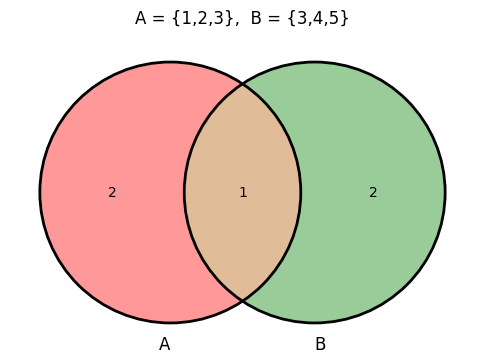

A = {1, 2, 3}
B = {3, 4, 5}
A ∩ B = {3}
A ∪ B = {1, 2, 3, 4, 5}


In [2]:
A = {1, 2, 3}
B = {3, 4, 5}

plt.figure(figsize=(6, 5))
v = venn2([A, B], set_labels=('A', 'B'))
venn2_circles([A, B])

plt.title('A = {1,2,3},  B = {3,4,5}')
plt.show()

print("A =", A)
print("B =", B)
print("A ∩ B =", A & B)
print("A ∪ B =", A | B)


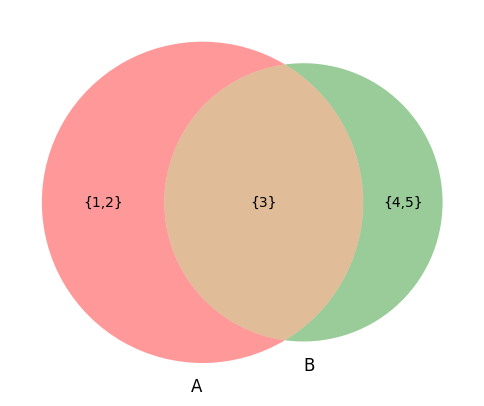

In [3]:
plt.figure(figsize=(6,5))
v = venn2(subsets=(2,1,2), set_labels=('A','B'))

v.get_label_by_id('10').set_text('{1,2}')
v.get_label_by_id('11').set_text('{3}')
v.get_label_by_id('01').set_text('{4,5}')

plt.show()

## 4. Membership

If $x \in A$, then $x$ belongs to set $A$.

If $x \notin A$, then $x$ does not belong to set $A$.

Example:

- $3 \in A$
- $5 \notin A$ if $A = \{1,2,3\}$


In [4]:
A = {1, 2, 3}

print("A =", A)
print("Is 3 in A?", 3 in A)
print("Is 5 in A?", 5 in A)


A = {1, 2, 3}
Is 3 in A? True
Is 5 in A? False


## 5. Union

The **union** contains everything that is in $A$ or in $B$ or in both:

$$
A \cup B
$$

For

$$
A = \{1,2,3\}, \qquad B = \{3,4,5\},
$$

we get:

$$
A \cup B = \{1,2,3,4,5\}.
$$

In the Venn diagram, this means **both circles entirely**.


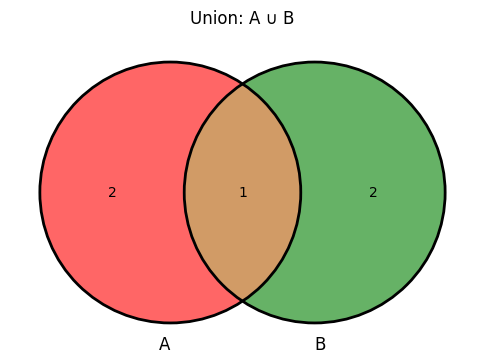

A ∪ B = {1, 2, 3, 4, 5}


In [6]:
A = {1, 2, 3}
B = {3, 4, 5}

plt.figure(figsize=(6, 5))
v = venn2([A, B], set_labels=('A', 'B'))
venn2_circles([A, B])

# Highlight all regions
for region in ['10', '11', '01']:
    patch = v.get_patch_by_id(region)
    if patch:
        patch.set_alpha(0.6)

plt.title('Union: A ∪ B')
plt.show()

print("A ∪ B =", A | B)


## 6. Intersection

The **intersection** contains the elements common to both sets:

$$
A \cap B
$$

For the same example:

$$
A \cap B = \{3\}.
$$

In the Venn diagram, this is **only the overlap**.


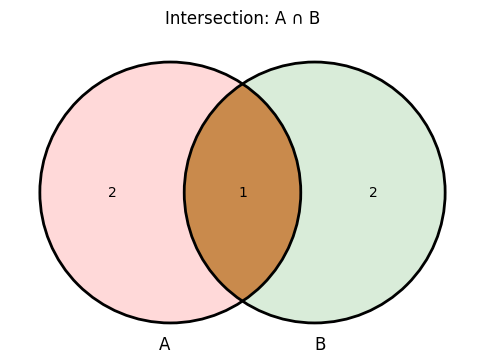

A ∩ B = {3}


In [7]:
A = {1, 2, 3}
B = {3, 4, 5}

plt.figure(figsize=(6, 5))
v = venn2([A, B], set_labels=('A', 'B'))
venn2_circles([A, B])

# Highlight only the overlap
patch = v.get_patch_by_id('11')
if patch:
    patch.set_alpha(0.7)

for region in ['10', '01']:
    patch = v.get_patch_by_id(region)
    if patch:
        patch.set_alpha(0.15)

plt.title('Intersection: A ∩ B')
plt.show()

print("A ∩ B =", A & B)


## 7. Difference

The **difference** $A \setminus B$ contains elements that are in $A$ but not in $B$:

$$
A \setminus B
$$

For our example:

$$
A \setminus B = \{1,2\}.
$$

In the Venn diagram, this is the **left-only** part.


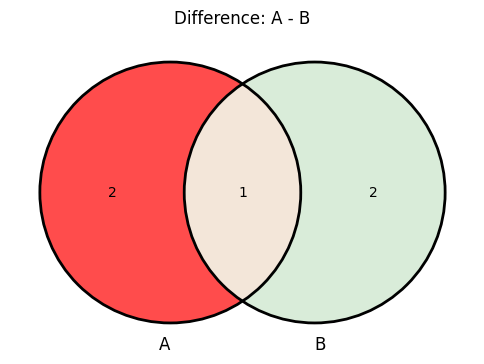

A - B = {1, 2}


In [8]:
A = {1, 2, 3}
B = {3, 4, 5}

plt.figure(figsize=(6, 5))
v = venn2([A, B], set_labels=('A', 'B'))
venn2_circles([A, B])

# Highlight only A \ B
patch = v.get_patch_by_id('10')
if patch:
    patch.set_alpha(0.7)

for region in ['11', '01']:
    patch = v.get_patch_by_id(region)
    if patch:
        patch.set_alpha(0.15)

plt.title('Difference: A - B')
plt.show()

print("A - B =", A - B)


## 8. Symmetric difference

The **symmetric difference** contains elements that are in exactly one of the two sets:

$$
A \triangle B = (A \setminus B) \cup (B \setminus A)
$$

For our example:

$$
A \triangle B = \{1,2,4,5\}.
$$

In the Venn diagram, this means the **non-overlapping parts**.


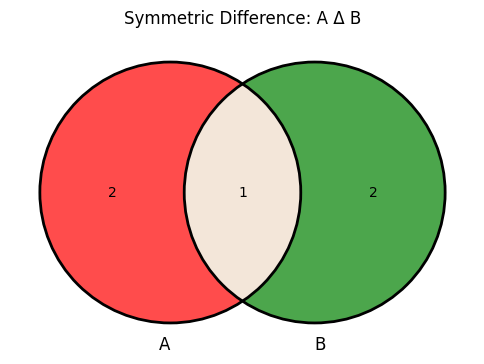

A ^ B = {1, 2, 4, 5}


In [9]:
A = {1, 2, 3}
B = {3, 4, 5}

plt.figure(figsize=(6, 5))
v = venn2([A, B], set_labels=('A', 'B'))
venn2_circles([A, B])

for region in ['10', '01']:
    patch = v.get_patch_by_id(region)
    if patch:
        patch.set_alpha(0.7)

patch = v.get_patch_by_id('11')
if patch:
    patch.set_alpha(0.15)

plt.title('Symmetric Difference: A Δ B')
plt.show()

print("A ^ B =", A ^ B)


## 9. Disjoint sets

Two sets are **disjoint** if they have no common elements:

$$
A \cap B = \varnothing
$$

Example:

$$
A = \{1,2\}, \qquad B = \{3,4\}.
$$

In the Venn diagram, the circles do not have a meaningful overlap in terms of elements.


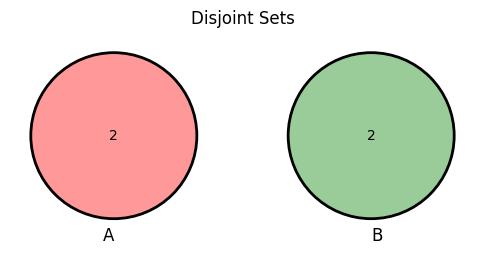

A = {1, 2}
B = {3, 4}
A ∩ B = set()
Disjoint? True


In [10]:
A = {1, 2}
B = {3, 4}

plt.figure(figsize=(6, 5))
v = venn2([A, B], set_labels=('A', 'B'))
venn2_circles([A, B])

plt.title('Disjoint Sets')
plt.show()

print("A =", A)
print("B =", B)
print("A ∩ B =", A & B)
print("Disjoint?", A.isdisjoint(B))


## 10. Subsets

If every element of $A$ is also an element of $B$, then

$$
A \subseteq B.
$$

Example:

$$
A = \{1,2\}, \qquad B = \{1,2,3,4\}.
$$

A Venn-style way to think about this is that the content of $A$ sits entirely inside $B$.

Standard two-circle Venn diagrams are not ideal for drawing true subset containment geometrically, but the set relation is easy to verify computationally.


In [11]:
A = {1, 2}
B = {1, 2, 3, 4}

print("A =", A)
print("B =", B)
print("A <= B ?", A <= B)   # subset
print("A < B  ?", A < B)    # proper subset
print("B >= A ?", B >= A)   # superset


A = {1, 2}
B = {1, 2, 3, 4}
A <= B ? True
A < B  ? True
B >= A ? True


## 11. Universal set and complement

Sometimes we work inside a **universal set** $U$.

If $A \subseteq U$, then the **complement** of $A$ in $U$ is:

$$
A^c = U \setminus A
$$

Example:

$$
U = \{1,2,3,4,5,6\}, \qquad A = \{1,2,3\}
$$

Then

$$
A^c = \{4,5,6\}.
$$

A classical Venn diagram often shows the universal set as a rectangle containing the circles.


In [12]:
U = {1, 2, 3, 4, 5, 6}
A = {1, 2, 3}

print("U =", U)
print("A =", A)
print("Complement of A in U =", U - A)


U = {1, 2, 3, 4, 5, 6}
A = {1, 2, 3}
Complement of A in U = {4, 5, 6}


### A simple complement visualization with Matplotlib

The next plot draws a rectangle for the universal set and a circle for $A$.
The shaded area outside the circle represents the complement of $A$ in $U$.


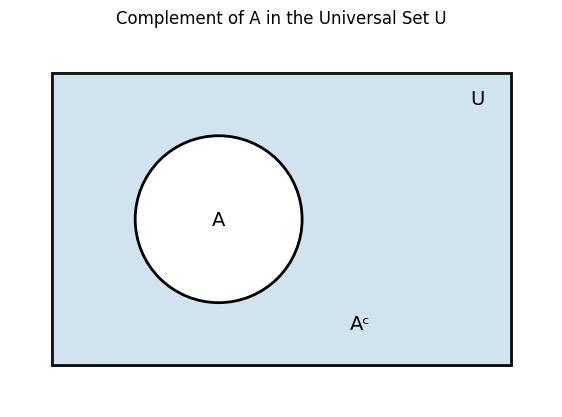

In [13]:
from matplotlib.patches import Rectangle, Circle

fig, ax = plt.subplots(figsize=(7, 5))

# Universal set rectangle
rect = Rectangle((0.5, 0.5), 5.5, 3.5, fill=False, linewidth=2)
ax.add_patch(rect)

# Shade whole universe lightly
shade_universe = Rectangle((0.5, 0.5), 5.5, 3.5, alpha=0.2)
ax.add_patch(shade_universe)

# White circle cuts out A visually
circle_fill = Circle((2.5, 2.25), 1.0, color='white')
ax.add_patch(circle_fill)

# Circle border
circle_border = Circle((2.5, 2.25), 1.0, fill=False, linewidth=2)
ax.add_patch(circle_border)

ax.text(2.5, 2.25, 'A', ha='center', va='center', fontsize=14)
ax.text(5.6, 3.7, 'U', ha='center', va='center', fontsize=14)
ax.text(4.2, 1.0, 'Aᶜ', ha='center', va='center', fontsize=14)

ax.set_xlim(0, 6.5)
ax.set_ylim(0, 4.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Complement of A in the Universal Set U')

plt.show()


## 12. Three-set Venn diagram

For three sets $A$, $B$, and $C$, we can use `venn3`.

This is useful for visualizing more complex overlaps.


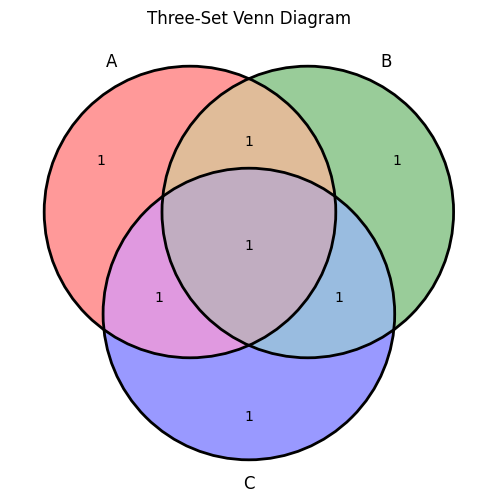

A = {1, 2, 3, 7}
B = {3, 4, 5, 7}
C = {2, 5, 6, 7}
A ∩ B ∩ C = {7}


In [14]:
A = {1, 2, 3, 7}
B = {3, 4, 5, 7}
C = {2, 5, 6, 7}

plt.figure(figsize=(7, 6))
v = venn3([A, B, C], set_labels=('A', 'B', 'C'))
venn3_circles([A, B, C])

plt.title('Three-Set Venn Diagram')
plt.show()

print("A =", A)
print("B =", B)
print("C =", C)
print("A ∩ B ∩ C =", A & B & C)


## 13. Core set principles summary

Here are the main ideas again:

- **Membership**: $x \in A$
- **Non-membership**: $x \notin A$
- **Subset**: $A \subseteq B$
- **Union**: $A \cup B$
- **Intersection**: $A \cap B$
- **Difference**: $A \setminus B$
- **Symmetric difference**: $A \triangle B$
- **Complement**: $A^c = U \setminus A$
- **Disjoint sets**: $A \cap B = \varnothing$

Venn diagrams are especially useful for building intuition about these operations.


## 14. A reusable helper function

The next cell defines a helper function for two-set Venn diagrams so you can quickly visualize different operations.


In [15]:
def plot_venn2_operation(A, B, title='Venn Diagram', highlight_regions=None):
    """
    highlight_regions:
        '10' -> A only
        '01' -> B only
        '11' -> overlap
    """
    if highlight_regions is None:
        highlight_regions = []

    plt.figure(figsize=(6, 5))
    v = venn2([A, B], set_labels=('A', 'B'))
    venn2_circles([A, B])

    all_regions = ['10', '11', '01']
    for region in all_regions:
        patch = v.get_patch_by_id(region)
        if patch:
            patch.set_alpha(0.15)

    for region in highlight_regions:
        patch = v.get_patch_by_id(region)
        if patch:
            patch.set_alpha(0.7)

    plt.title(title)
    plt.show()


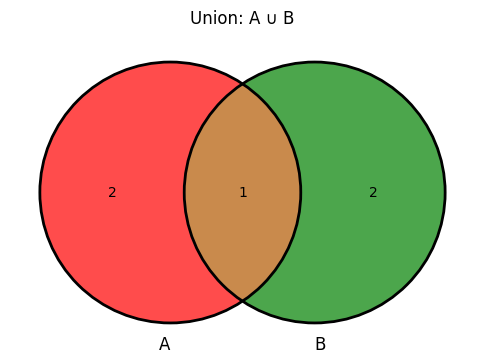

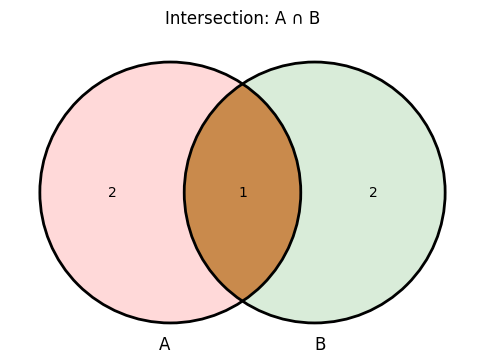

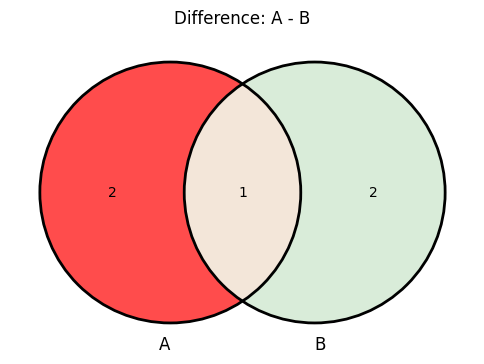

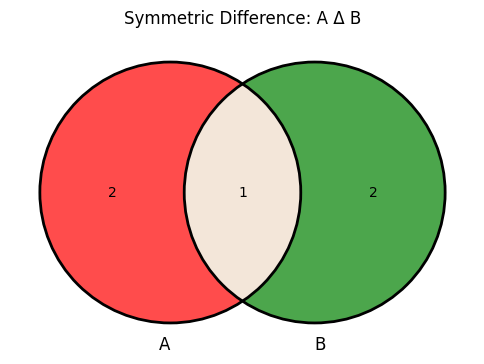

In [16]:
A = {1, 2, 3}
B = {3, 4, 5}

plot_venn2_operation(A, B, title='Union: A ∪ B', highlight_regions=['10', '11', '01'])
plot_venn2_operation(A, B, title='Intersection: A ∩ B', highlight_regions=['11'])
plot_venn2_operation(A, B, title='Difference: A - B', highlight_regions=['10'])
plot_venn2_operation(A, B, title='Symmetric Difference: A Δ B', highlight_regions=['10', '01'])


## 15. Small exercises

Try changing the sets below and predict what the diagrams should show before running the cells.

1. Choose two sets with one common element.
2. Choose two disjoint sets.
3. Choose one set that is a subset of another.
4. Choose three sets and inspect the triple overlap.


A = {1, 2, 3, 4}
B = {3, 4, 5, 6}
A ∪ B = {1, 2, 3, 4, 5, 6}
A ∩ B = {3, 4}
A - B = {1, 2}
A ^ B = {1, 2, 5, 6}


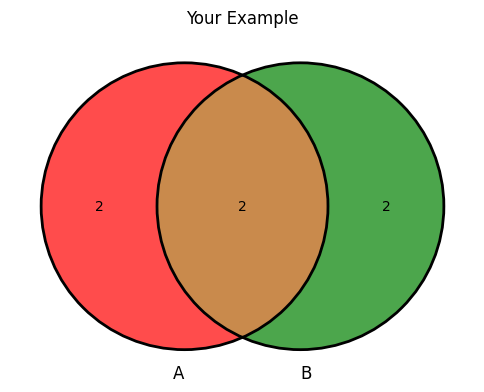

In [17]:
# Experiment here

A = {1, 2, 3, 4}
B = {3, 4, 5, 6}

print("A =", A)
print("B =", B)
print("A ∪ B =", A | B)
print("A ∩ B =", A & B)
print("A - B =", A - B)
print("A ^ B =", A ^ B)

plot_venn2_operation(A, B, title='Your Example', highlight_regions=['10', '11', '01'])


## 16. Final remark

For **two** and **three** sets, Venn diagrams are excellent teaching and intuition tools.

For larger numbers of sets, they become harder to read, and it is often better to use:

- direct set operations in Python
- tables
- logic expressions
- combinatorial reasoning

But for the core principles of set theory, Venn diagrams are one of the best visual tools.
